# Step 1: Lambert Conformal Grid Setup & PARAM

Set up the Lambert Conformal Conic (LCC) projection grid and compute the PARAM arrays:
- Map factor $m(i,j)$ and its gradients $\partial m/\partial x$, $\partial m/\partial y$
- Coriolis parameter $f(i,j)$
- Interpolate ERA5 data (z, u, v at 500 hPa) onto the model grid

**Projection:** LCC with reference point 35°N 115°E, standard parallels 25°N/45°N  
**Grid:** 60 × 50 points, spacing d = 100 km

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj
from scipy.interpolate import RegularGridInterpolator
import os

# Physical constants
g = 9.80665          # gravity (m/s^2)
Omega = 7.292e-5     # earth rotation rate (rad/s)
R_earth = 6371000.0  # earth radius (m)

# LCC projection parameters (cheatsheet recommended)
lat_0 = 35.0   # reference latitude (deg N)
lon_0 = 115.0  # reference longitude (deg E)
lat_1 = 25.0   # standard parallel 1 (deg N)
lat_2 = 45.0   # standard parallel 2 (deg N)

# Grid parameters
d = 100_000.0  # grid spacing (m) = 100 km
nx = 60        # grid points in x (east-west)
ny = 50        # grid points in y (north-south)

## 1. Create LCC Projection and Model Grid

In [2]:
# Define Lambert Conformal Conic projection
proj_lcc = Proj(proj='lcc', lat_0=lat_0, lon_0=lon_0,
                lat_1=lat_1, lat_2=lat_2,
                R=R_earth, x_0=0, y_0=0)

# Create regular grid in projection plane, centered at reference point (0, 0)
X_1d = (np.arange(nx) - (nx - 1) / 2) * d  # shape (nx,)
Y_1d = (np.arange(ny) - (ny - 1) / 2) * d  # shape (ny,)

# 2D grid arrays: X_2d[j, i], Y_2d[j, i]
# j = row index (y-direction, south to north)
# i = column index (x-direction, west to east)
X_2d, Y_2d = np.meshgrid(X_1d, Y_1d)  # shape (ny, nx)

print(f'Grid size: {ny} rows x {nx} cols')
print(f'X range: {X_1d[0]/1e3:.0f} to {X_1d[-1]/1e3:.0f} km')
print(f'Y range: {Y_1d[0]/1e3:.0f} to {Y_1d[-1]/1e3:.0f} km')
print(f'Domain extent: {(nx-1)*d/1e3:.0f} km x {(ny-1)*d/1e3:.0f} km')

Grid size: 50 rows x 60 cols
X range: -2950 to 2950 km
Y range: -2450 to 2450 km
Domain extent: 5900 km x 4900 km


## 2. Inverse Projection: Grid Point Lat/Lon

In [3]:
# Compute geographic coordinates for each grid point
lon_grid, lat_grid = proj_lcc(X_2d, Y_2d, inverse=True)

print(f'Latitude  range: {lat_grid.min():.2f} to {lat_grid.max():.2f} deg N')
print(f'Longitude range: {lon_grid.min():.2f} to {lon_grid.max():.2f} deg E')
print(f'Center point: lat={lat_grid[ny//2, nx//2]:.2f}, lon={lon_grid[ny//2, nx//2]:.2f}')

Latitude  range: 9.98 to 56.80 deg N
Longitude range: 72.45 to 157.55 deg E
Center point: lat=35.46, lon=115.56


## 3. Compute PARAM: Map Factor $m$ and Coriolis $f$

In [4]:
# --- Coriolis parameter f(i,j) ---
lat_rad = np.deg2rad(lat_grid)
f_cor = 2 * Omega * np.sin(lat_rad)

# --- Map factor m(phi) for LCC ---
# m(phi) = (cos(phi1)/cos(phi)) * [tan(pi/4+phi1/2)/tan(pi/4+phi/2)]^n
# n = (ln cos(phi1) - ln cos(phi2)) / (ln tan(pi/4+phi2/2) - ln tan(pi/4+phi1/2))
phi1 = np.deg2rad(lat_1)
phi2 = np.deg2rad(lat_2)

n_lcc = (np.log(np.cos(phi1)) - np.log(np.cos(phi2))) / \
        (np.log(np.tan(np.pi/4 + phi2/2)) - np.log(np.tan(np.pi/4 + phi1/2)))

m_map = (np.cos(phi1) / np.cos(lat_rad)) * \
        (np.tan(np.pi/4 + phi1/2) / np.tan(np.pi/4 + lat_rad/2)) ** n_lcc

print(f'n (cone constant) = {n_lcc:.6f}')
print(f'Map factor range: {m_map.min():.6f} to {m_map.max():.6f}')

# Verify m = 1 at standard parallels
for sp in [lat_1, lat_2]:
    idx = np.unravel_index(np.argmin(np.abs(lat_grid - sp)), lat_grid.shape)
    print(f'  m at lat={lat_grid[idx]:.1f} (near standard parallel {sp}): {m_map[idx]:.6f}')

# --- dm/dx, dm/dy using centred differences ---
dm_dx = np.zeros_like(m_map)
dm_dy = np.zeros_like(m_map)

# Interior: centred differences
dm_dx[:, 1:-1] = (m_map[:, 2:] - m_map[:, :-2]) / (2 * d)
dm_dy[1:-1, :] = (m_map[2:, :] - m_map[:-2, :]) / (2 * d)

# Boundary: one-sided differences
dm_dx[:, 0]  = (m_map[:, 1]  - m_map[:, 0])  / d
dm_dx[:, -1] = (m_map[:, -1] - m_map[:, -2]) / d
dm_dy[0, :]  = (m_map[1, :]  - m_map[0, :])  / d
dm_dy[-1, :] = (m_map[-1, :] - m_map[-2, :]) / d

print(f'\nCoriolis f range: {f_cor.min():.6e} to {f_cor.max():.6e} s^-1')
print(f'dm/dx range: {dm_dx.min():.2e} to {dm_dx.max():.2e} m^-1')
print(f'dm/dy range: {dm_dy.min():.2e} to {dm_dy.max():.2e} m^-1')

n (cone constant) = 0.576535
Map factor range: 0.984782 to 1.078817
  m at lat=25.0 (near standard parallel 25.0): 1.000086
  m at lat=45.0 (near standard parallel 45.0): 1.000065

Coriolis f range: 2.528060e-05 to 1.220294e-04 s^-1
dm/dx range: -2.12e-08 to 2.12e-08 m^-1
dm/dy range: -6.12e-08 to 7.26e-08 m^-1


## 4. Interpolate ERA5 Data onto Model Grid

In [5]:
# Read ERA5 data
data_dir = '/Users/weiyingwan/Desktop/校内课程/大三下/数值天气预报/project/data'
ds_z  = xr.open_dataset(os.path.join(data_dir, '2026JanFeb.nc'))
ds_uv = xr.open_dataset(os.path.join(data_dir, '2026JanFeb.nc'))

# Select initial time: Jan 12 00 UTC
t0 = '2026-02-17T00:00'

# Extract 2D fields at t0, 500 hPa
z_era5 = ds_z['z'].sel(valid_time=t0, pressure_level=500).squeeze().values   # m^2/s^2
u_era5 = ds_uv['u'].sel(valid_time=t0, pressure_level=500).squeeze().values  # m/s
v_era5 = ds_uv['v'].sel(valid_time=t0, pressure_level=500).squeeze().values  # m/s

# Convert geopotential to geopotential height (gpm)
z_era5_gpm = z_era5 / g

# ERA5 coordinate arrays
lat_era5_z  = ds_z['latitude'].values    # decreasing: 70 -> 10
lon_era5_z  = ds_z['longitude'].values   # increasing: 70 -> 150
lat_era5_uv = ds_uv['latitude'].values
lon_era5_uv = ds_uv['longitude'].values

# ERA5 latitude is decreasing — flip to increasing for RegularGridInterpolator
lat_z_inc  = lat_era5_z[::-1]
lat_uv_inc = lat_era5_uv[::-1]

z_era5_gpm_flip = z_era5_gpm[::-1, :]
u_era5_flip     = u_era5[::-1, :]
v_era5_flip     = v_era5[::-1, :]

# Build interpolators (bilinear)
rgi_z = RegularGridInterpolator((lat_z_inc, lon_era5_z),   z_era5_gpm_flip, method='linear', bounds_error=False)
rgi_u = RegularGridInterpolator((lat_uv_inc, lon_era5_uv), u_era5_flip,     method='linear', bounds_error=False)
rgi_v = RegularGridInterpolator((lat_uv_inc, lon_era5_uv), v_era5_flip,     method='linear', bounds_error=False)

# Interpolate onto model grid
target_pts = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])

z_model = rgi_z(target_pts).reshape(ny, nx)
u_model = rgi_u(target_pts).reshape(ny, nx)
v_model = rgi_v(target_pts).reshape(ny, nx)

print(f'Interpolated z: {np.nanmin(z_model):.1f} ~ {np.nanmax(z_model):.1f} gpm')
print(f'Interpolated u: {np.nanmin(u_model):.1f} ~ {np.nanmax(u_model):.1f} m/s')
print(f'Interpolated v: {np.nanmin(v_model):.1f} ~ {np.nanmax(v_model):.1f} m/s')

# Check for NaN (grid points outside ERA5 domain)
n_nan_z = np.isnan(z_model).sum()
n_nan_u = np.isnan(u_model).sum()
if n_nan_z > 0 or n_nan_u > 0:
    print(f'WARNING: {n_nan_z} z NaN, {n_nan_u} u NaN — grid points outside ERA5 domain')
else:
    print('All grid points successfully interpolated (no NaN)')

Interpolated z: 4972.7 ~ 5894.1 gpm
Interpolated u: -12.0 ~ 42.0 m/s
Interpolated v: -41.1 ~ 20.1 m/s
All grid points successfully interpolated (no NaN)


## 5. Verification Plots

Cheatsheet Tip #1: *Verify the IC before integrating. A 90° rotation or hemisphere flip from a lat/lon axis-order bug is the single most common error.*

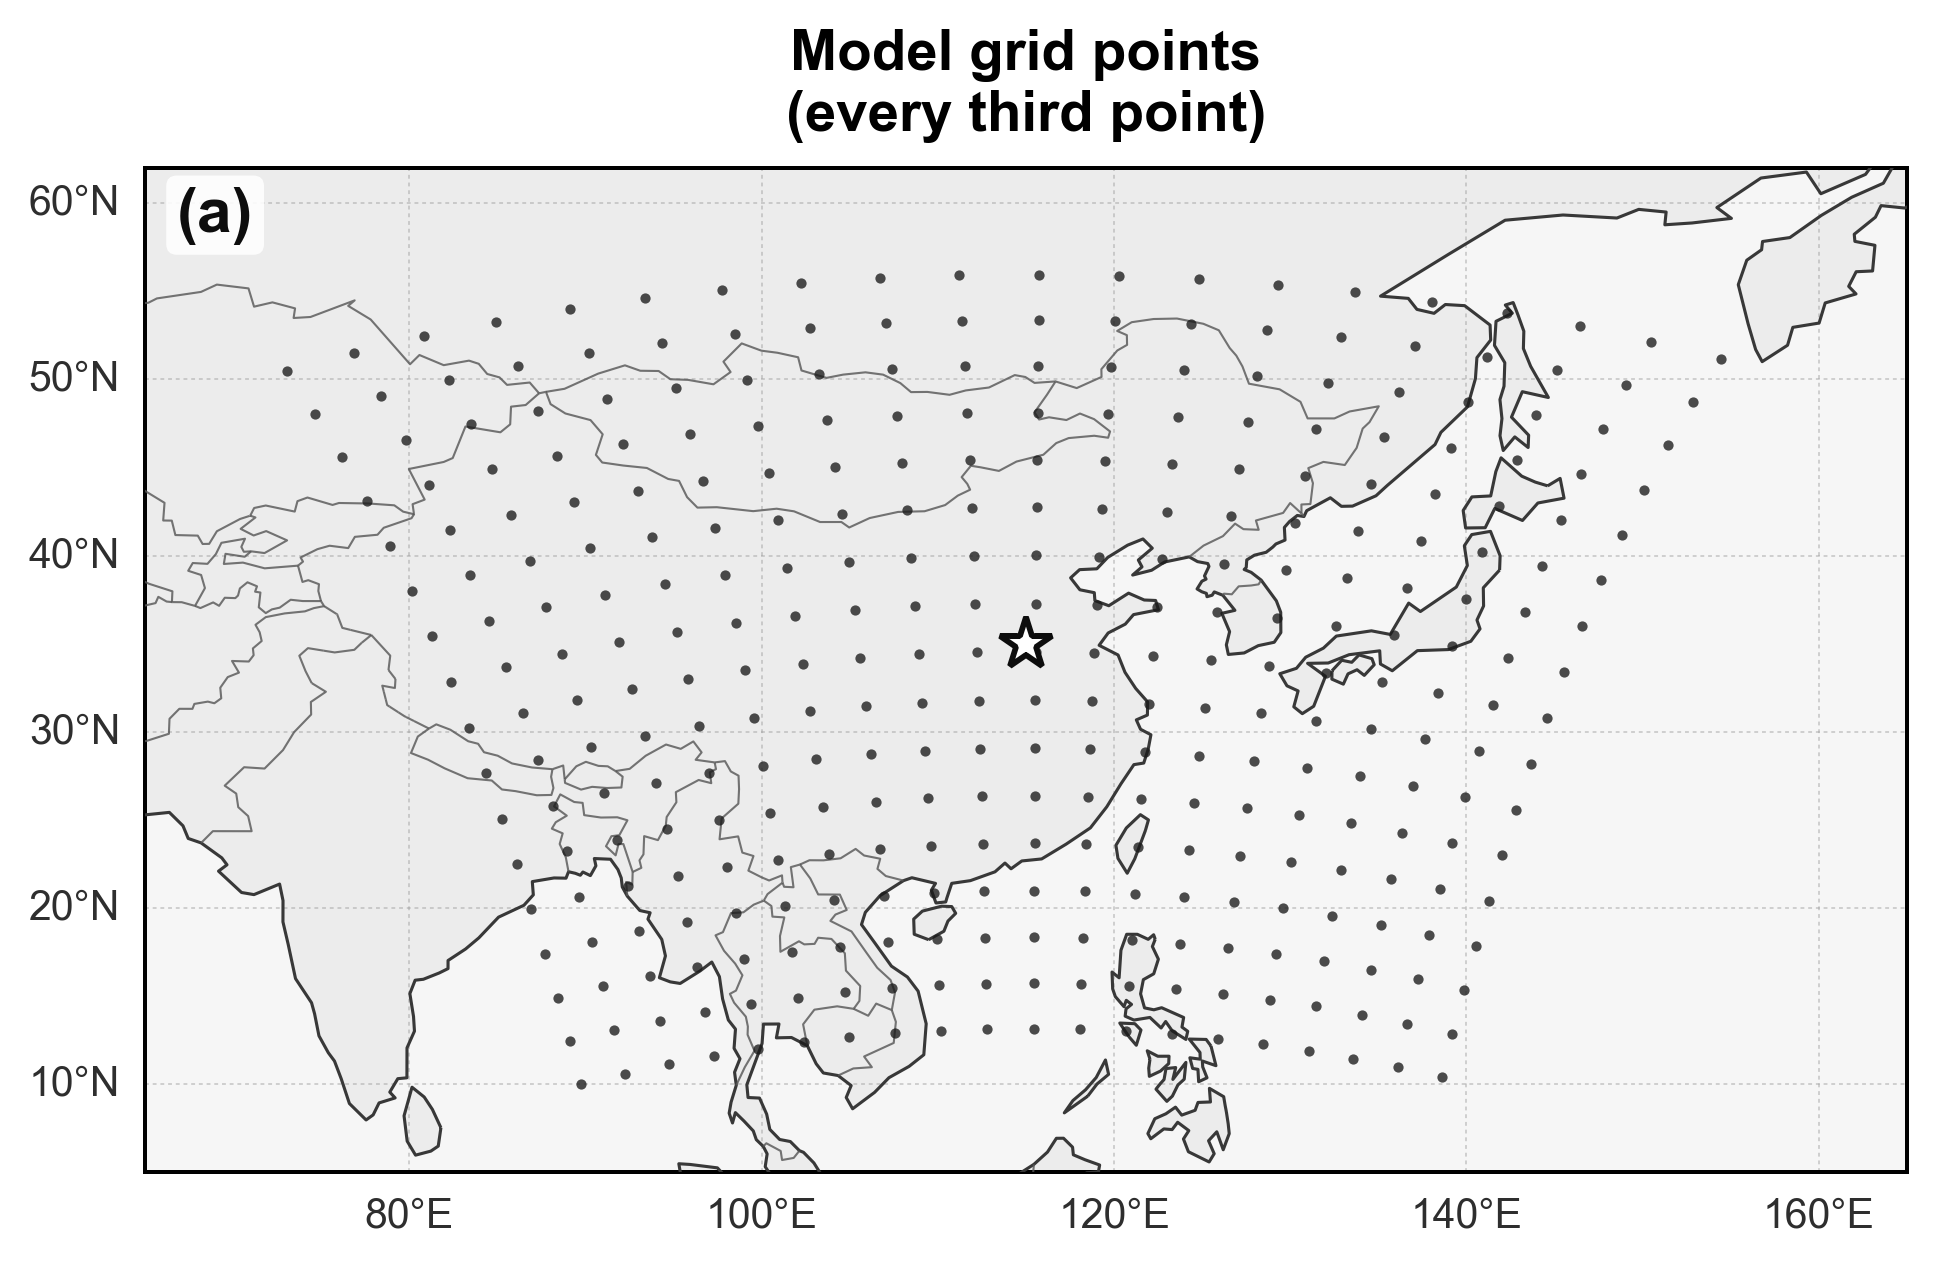

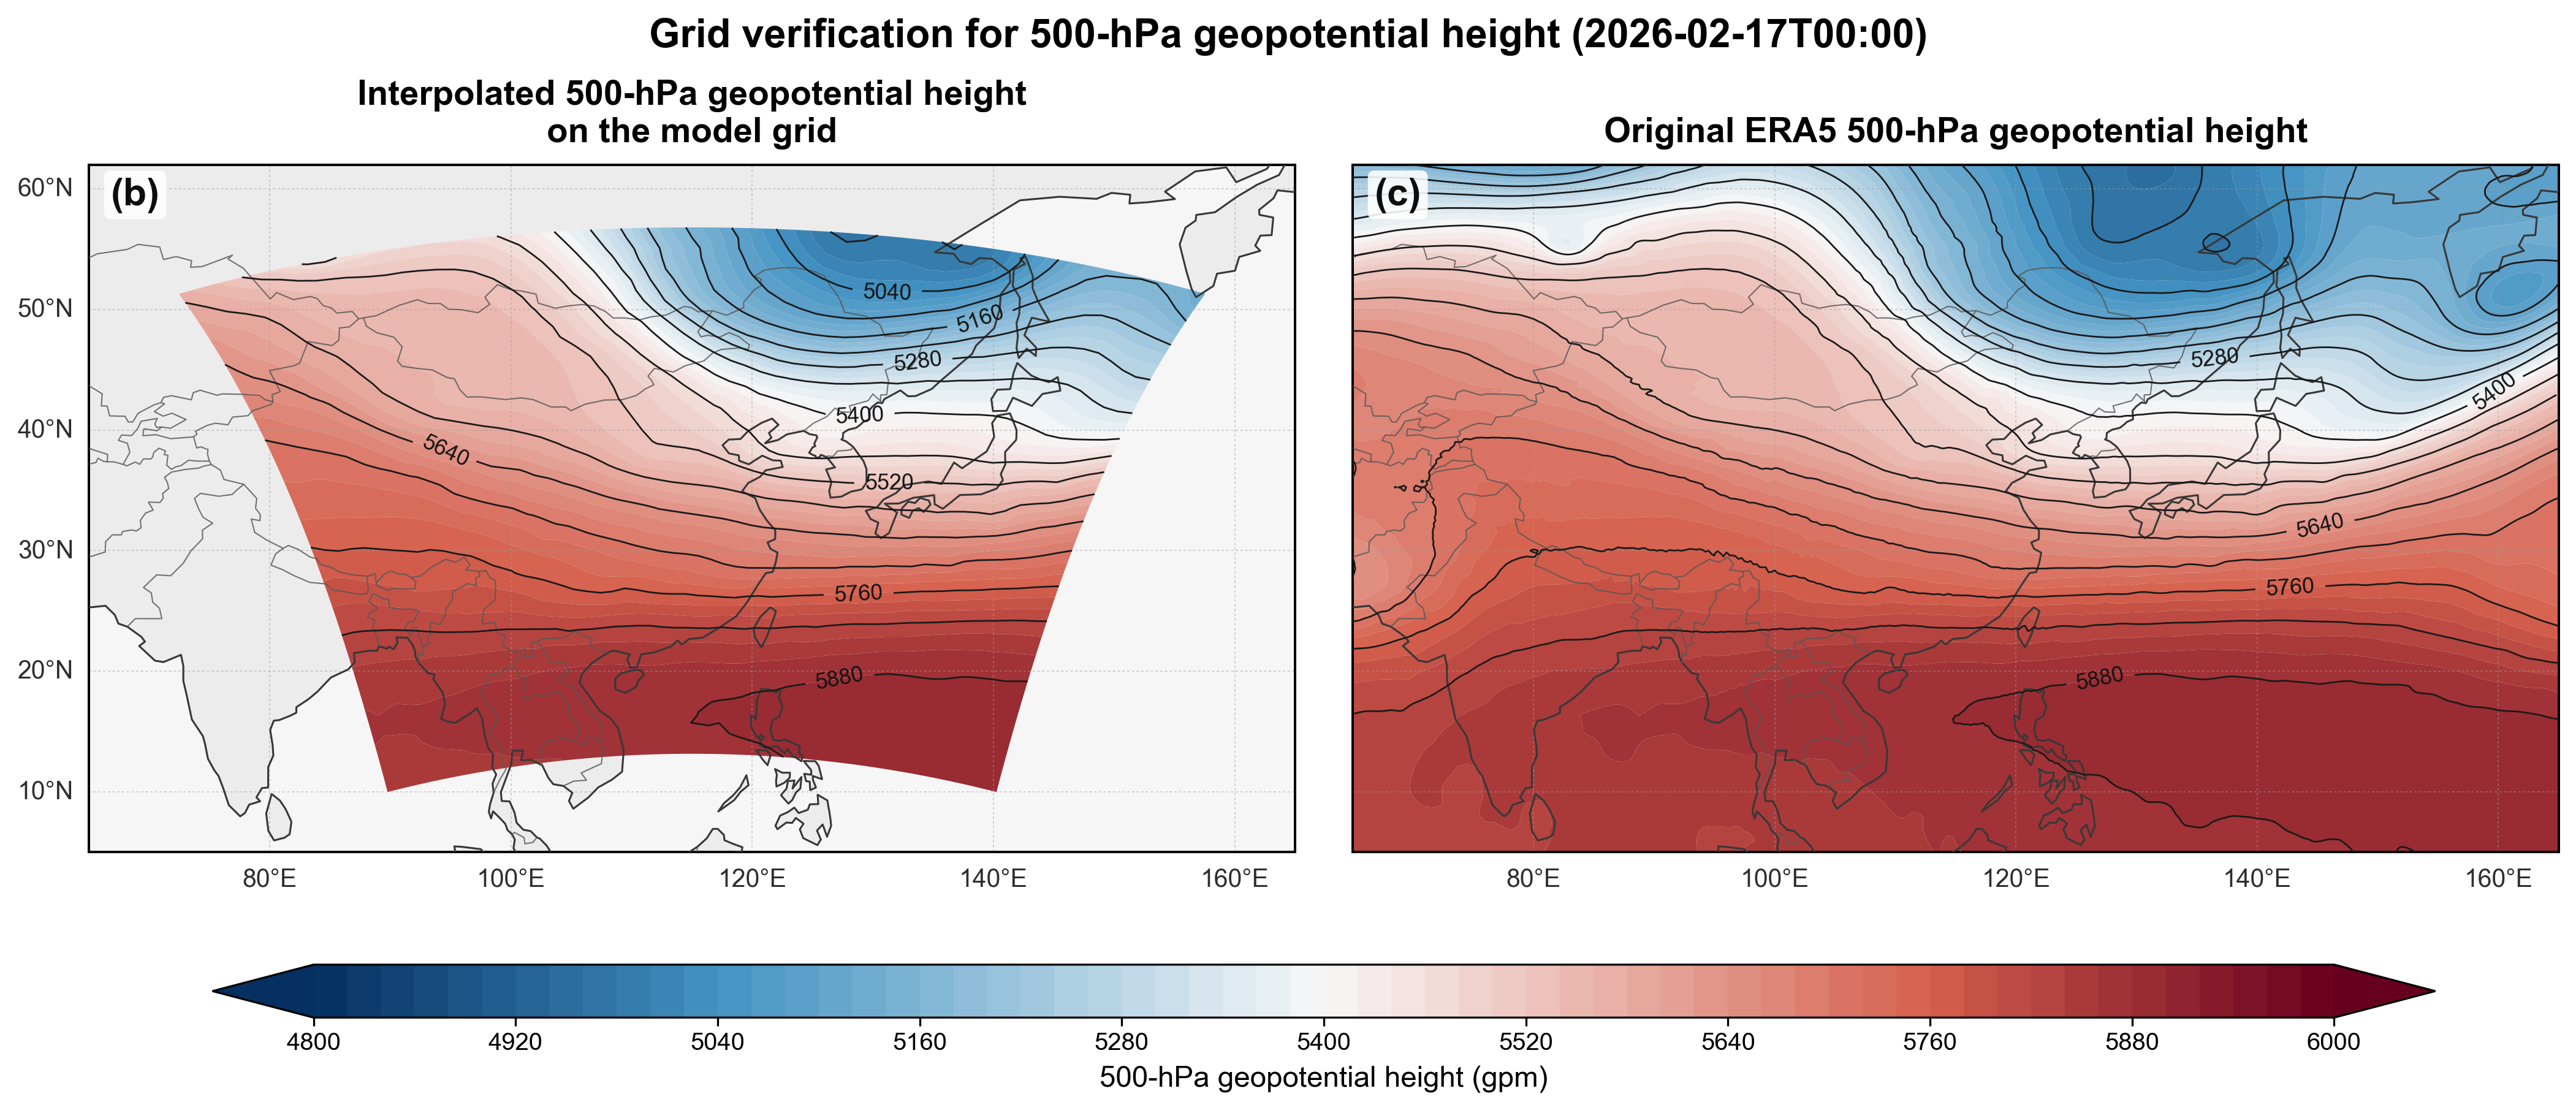

In [6]:
# Publication-quality figure: grid verification
# Split into two figures:
# Figure 1: panel (a) only
# Figure 2: panels (b) and (c)

import os
import matplotlib as mpl
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

OUTPUT_FIG_DIR = "/Users/weiyingwan/Desktop/校内课程/大三下/数值天气预报/project/figures/01_grid"
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)

# Sharper display in Jupyter / Retina screens.
try:
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

# ===== User-selected IPCC continuous colormap path =====
cmap_z500_path = "/Users/weiyingwan/Desktop/科研/绘图/color bar/IPCC/continous/temp_div.txt"

def load_ipcc_continuous_cmap(path, name, N=256):
    """
    Robustly load a continuous IPCC .txt colormap.

    Supported formats:
        R G B
        R G B A
        temp_div_5 R G B

    Non-numeric labels are ignored. RGB values can be either 0-255 or 0-1.
    """
    rgb_rows = []

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()

            if (
                not line
                or line.startswith("#")
                or line.startswith("%")
                or line.startswith("//")
            ):
                continue

            for sep in [",", ";", "\t"]:
                line = line.replace(sep, " ")

            nums = []
            for token in line.split():
                try:
                    nums.append(float(token))
                except ValueError:
                    pass

            if len(nums) >= 3:
                rgb_rows.append(nums[-3:])

    if len(rgb_rows) == 0:
        raise ValueError(
            f"No valid RGB rows were found in {path}. "
            "Please check whether the colormap file contains numeric RGB columns."
        )

    colors = np.asarray(rgb_rows, dtype=float)

    if np.nanmax(colors) > 1.0:
        colors = colors / 255.0

    colors = np.clip(colors, 0, 1)
    return LinearSegmentedColormap.from_list(name, colors, N=N)

cmap_z500 = load_ipcc_continuous_cmap(cmap_z500_path, "IPCC_temp_div", N=256)

# ===== Publication-level style =====
PUB_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9.5,
    "axes.titlesize": 11.3,
    "axes.titleweight": "semibold",
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.2,
    "ytick.labelsize": 8.2,
    "figure.titlesize": 13,
    "figure.titleweight": "semibold",
    "text.antialiased": True,
    "axes.linewidth": 0.8,
    "savefig.dpi": 600,
    "figure.dpi": 180,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.08,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}

map_extent = [65, 165, 5, 62]

# Filled shading: fine levels for smooth visual transition.
# Contour lines: coarser synoptic interval for readability.
levels_z_filled = np.arange(4800, 6000 + 20, 20)
levels_z_line   = np.arange(4800, 6000 + 60, 60)

def add_publication_map_background(ax, extent=map_extent, label_left=True, label_bottom=True):
    """Add consistent map background and gridline style for publication-quality Cartopy panels."""
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_facecolor("white")

    ax.add_feature(cfeature.OCEAN, facecolor="0.965", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.LAND,  facecolor="0.925", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.62, edgecolor="0.22", zorder=5)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"), linewidth=0.42, edgecolor="0.34",
                   linestyle="-", alpha=0.82, zorder=5)

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.35,
        color="0.62",
        alpha=0.50,
        linestyle=(0, (2.2, 2.2)),
        zorder=4,
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = label_left
    gl.bottom_labels = label_bottom
    gl.xlocator = mticker.FixedLocator(np.arange(60, 181, 20))
    gl.ylocator = mticker.FixedLocator(np.arange(0, 71, 10))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 8.2, "color": "0.18"}
    gl.ylabel_style = {"size": 8.2, "color": "0.18"}
    return gl

def add_panel_label(ax, label):
    ax.text(
        0.018, 0.982, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12.5,
        fontweight="bold",
        color="0.05",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.88, boxstyle="round,pad=0.17"),
        zorder=30,
    )

with plt.rc_context(PUB_RC):

    # ==========================================================
    # Figure 1: panel (a) only
    # ==========================================================
    fig, ax = plt.subplots(
        1, 1,
        figsize=(5.3, 4.6),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )
    fig.patch.set_facecolor("white")

    add_publication_map_background(ax, label_left=True, label_bottom=True)
    ax.scatter(
        lon_grid[::3, ::3], lat_grid[::3, ::3],
        s=4.2,
        c="0.10",
        marker="o",
        linewidths=0,
        alpha=0.78,
        transform=ccrs.PlateCarree(),
        zorder=9,
        rasterized=True,
    )
    ax.plot(
        lon_0, lat_0,
        marker="*",
        markersize=11.0,
        markerfacecolor="white",
        markeredgecolor="0.05",
        markeredgewidth=1.15,
        linestyle="None",
        transform=ccrs.PlateCarree(),
        zorder=12,
    )
    ax.set_title("Model grid points\n(every third point)", pad=7.5)
    add_panel_label(ax, "(a)")

    plt.savefig(os.path.join(OUTPUT_FIG_DIR, "01_grid_points.png"), dpi=600, bbox_inches="tight",
                pad_inches=0.08, facecolor="white")
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, "01_grid_points.pdf"), bbox_inches="tight",
                pad_inches=0.08, facecolor="white")
    plt.show()

    # ==========================================================
    # Figure 2: panels (b) and (c)
    # ==========================================================
    fig, axes = plt.subplots(
        1, 2,
        figsize=(11.6, 4.75),
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={"wspace": 0.045},
        constrained_layout=True,
    )
    fig.patch.set_facecolor("white")

    # --- Panel 2: Interpolated Z500 on model grid ---
    ax = axes[0]
    add_publication_map_background(ax, label_left=True, label_bottom=True)
    cf = ax.contourf(
        lon_grid, lat_grid, z_model,
        levels=levels_z_filled,
        cmap=cmap_z500,
        extend="both",
        transform=ccrs.PlateCarree(),
        zorder=1,
        antialiased=True,
    )
    cs = ax.contour(
        lon_grid, lat_grid, z_model,
        levels=levels_z_line,
        colors="0.10",
        linewidths=0.55,
        transform=ccrs.PlateCarree(),
        zorder=8,
    )
    ax.clabel(
        cs,
        levels=levels_z_line[::2],
        inline=True,
        inline_spacing=3,
        fontsize=7.2,
        fmt="%d",
        colors="0.08",
    )
    ax.set_title("Interpolated 500-hPa geopotential height\non the model grid", pad=7.5)
    add_panel_label(ax, "(b)")

    # --- Panel 3: ERA5 original Z500 ---
    ax = axes[1]
    add_publication_map_background(ax, label_left=False, label_bottom=True)
    cf = ax.contourf(
        lon_era5_z, lat_era5_z, z_era5_gpm,
        levels=levels_z_filled,
        cmap=cmap_z500,
        extend="both",
        transform=ccrs.PlateCarree(),
        zorder=1,
        antialiased=True,
    )
    cs = ax.contour(
        lon_era5_z, lat_era5_z, z_era5_gpm,
        levels=levels_z_line,
        colors="0.10",
        linewidths=0.55,
        transform=ccrs.PlateCarree(),
        zorder=8,
    )
    ax.clabel(
        cs,
        levels=levels_z_line[::2],
        inline=True,
        inline_spacing=3,
        fontsize=7.2,
        fmt="%d",
        colors="0.08",
    )
    ax.set_title("Original ERA5 500-hPa geopotential height", pad=7.5)
    add_panel_label(ax, "(c)")

    cbar = fig.colorbar(
        cf,
        ax=axes,
        orientation="horizontal",
        shrink=0.90,
        aspect=42,
        pad=0.08,
        ticks=np.arange(4800, 6000 + 120, 120),
        extend="both",
        spacing="proportional",
    )
    cbar.set_label("500-hPa geopotential height (gpm)", labelpad=3.5, fontsize=9.5)
    cbar.ax.tick_params(labelsize=8.0, length=2.8, width=0.65, pad=2)
    cbar.outline.set_linewidth(0.65)

    fig.suptitle(f"Grid verification for 500-hPa geopotential height ({t0})", y=1.03)

    plt.savefig(os.path.join(OUTPUT_FIG_DIR, "01_grid_verification_z500.png"), dpi=600, bbox_inches="tight",
                pad_inches=0.08, facecolor="white")
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, "01_grid_verification_z500.pdf"), bbox_inches="tight",
                pad_inches=0.08, facecolor="white")
    plt.show()


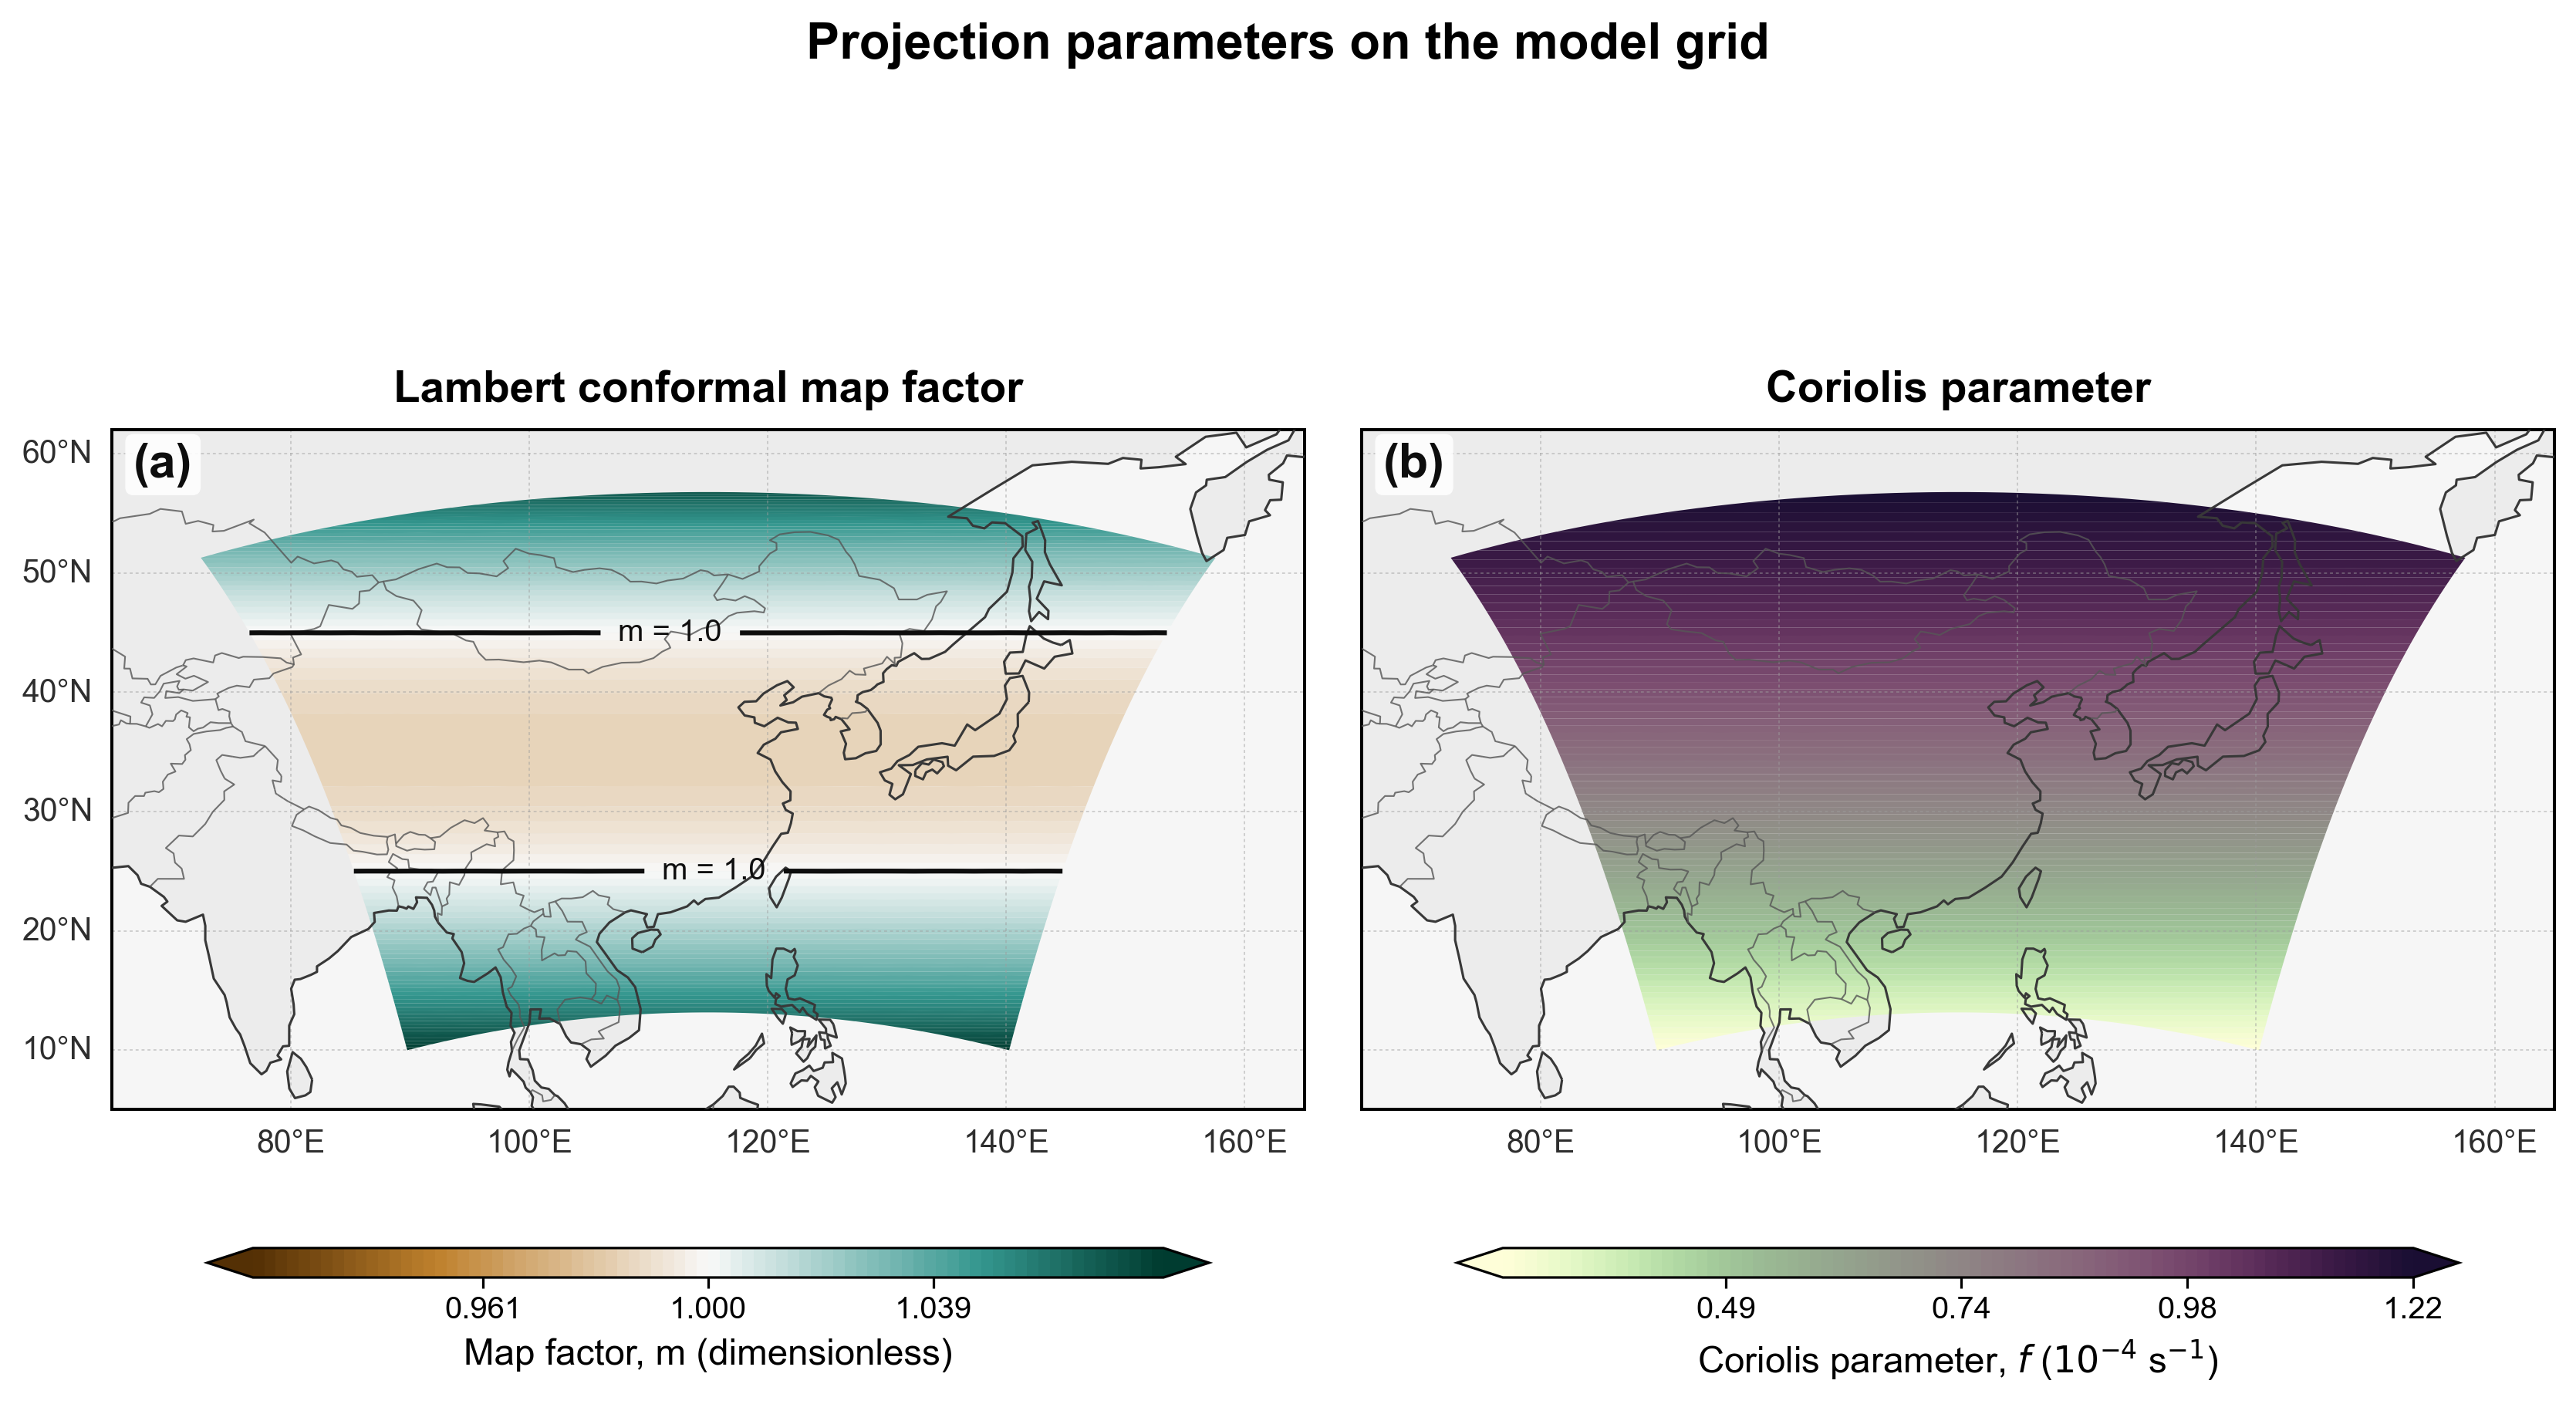

In [7]:
# Publication-quality figure: map factor and Coriolis parameter
# Only plotting style/layout/colorbar style is modified. Data processing and variables are unchanged.

import os
import matplotlib as mpl
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

OUTPUT_FIG_DIR = "/Users/weiyingwan/Desktop/校内课程/大三下/数值天气预报/project/figures/01_grid"
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)

try:
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

# ===== User-selected IPCC continuous colormap paths =====
cmap_m_path = "/Users/weiyingwan/Desktop/科研/绘图/color bar/IPCC/continous/prec_div.txt"
cmap_f_path = "/Users/weiyingwan/Desktop/科研/绘图/color bar/IPCC/continous/chem_seq.txt"

def load_ipcc_continuous_cmap(path, name, N=256):
    """
    Robustly load a continuous IPCC .txt colormap.

    Supported formats:
        R G B
        R G B A
        prec_div_5 R G B

    Non-numeric labels are ignored. RGB values can be either 0-255 or 0-1.
    """
    rgb_rows = []

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()

            if (
                not line
                or line.startswith("#")
                or line.startswith("%")
                or line.startswith("//")
            ):
                continue

            for sep in [",", ";", "\t"]:
                line = line.replace(sep, " ")

            nums = []
            for token in line.split():
                try:
                    nums.append(float(token))
                except ValueError:
                    pass

            if len(nums) >= 3:
                rgb_rows.append(nums[-3:])

    if len(rgb_rows) == 0:
        raise ValueError(
            f"No valid RGB rows were found in {path}. "
            "Please check whether the colormap file contains numeric RGB columns."
        )

    colors = np.asarray(rgb_rows, dtype=float)

    if np.nanmax(colors) > 1.0:
        colors = colors / 255.0

    colors = np.clip(colors, 0, 1)
    return LinearSegmentedColormap.from_list(name, colors, N=N)

cmap_m = load_ipcc_continuous_cmap(cmap_m_path, "IPCC_prec_div", N=256)
cmap_f = load_ipcc_continuous_cmap(cmap_f_path, "IPCC_chem_seq", N=256)

PUB_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9.5,
    "axes.titlesize": 11.3,
    "axes.titleweight": "semibold",
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.2,
    "ytick.labelsize": 8.2,
    "figure.titlesize": 13,
    "figure.titleweight": "semibold",
    "text.antialiased": True,
    "axes.linewidth": 0.8,
    "savefig.dpi": 600,
    "figure.dpi": 180,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.08,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}

def add_publication_map_background(ax, extent=map_extent, label_left=True, label_bottom=True):
    """Add consistent map background and gridline style for publication-quality Cartopy panels."""
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_facecolor("white")

    ax.add_feature(cfeature.OCEAN, facecolor="0.965", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.LAND,  facecolor="0.925", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.62, edgecolor="0.22", zorder=5)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"), linewidth=0.42, edgecolor="0.34",
                   linestyle="-", alpha=0.82, zorder=5)

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.35,
        color="0.62",
        alpha=0.50,
        linestyle=(0, (2.2, 2.2)),
        zorder=4,
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = label_left
    gl.bottom_labels = label_bottom
    gl.xlocator = mticker.FixedLocator(np.arange(60, 181, 20))
    gl.ylocator = mticker.FixedLocator(np.arange(0, 71, 10))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 8.2, "color": "0.18"}
    gl.ylabel_style = {"size": 8.2, "color": "0.18"}
    return gl

def add_panel_label(ax, label):
    ax.text(
        0.018, 0.982, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12.5,
        fontweight="bold",
        color="0.05",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.88, boxstyle="round,pad=0.17"),
        zorder=30,
    )

with plt.rc_context(PUB_RC):
    fig, axes = plt.subplots(
        1, 2,
        figsize=(9.2, 4.75),
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={"wspace": 0.045},
        constrained_layout=True,
    )
    fig.patch.set_facecolor("white")

    # --- Panel 1: Map factor m ---
    ax = axes[0]
    add_publication_map_background(ax, label_left=True, label_bottom=True)

    # m = 1 is the physical reference for no projection-scale distortion.
    m_dev = max(abs(np.nanmin(m_map) - 1.0), abs(np.nanmax(m_map) - 1.0))
    levels_m_filled = np.linspace(1.0 - m_dev, 1.0 + m_dev, 81)
    levels_m_ticks  = np.linspace(1.0 - m_dev, 1.0 + m_dev, 5)

    cf1 = ax.contourf(
        lon_grid, lat_grid, m_map,
        levels=levels_m_filled,
        cmap=cmap_m,
        extend="both",
        transform=ccrs.PlateCarree(),
        zorder=1,
        antialiased=True,
    )
    cs = ax.contour(
        lon_grid, lat_grid, m_map,
        levels=[1.0],
        colors="0.05",
        linewidths=1.25,
        transform=ccrs.PlateCarree(),
        zorder=8,
    )
    ax.clabel(cs, inline=True, inline_spacing=3, fontsize=8.0, fmt="m = %.1f", colors="0.05")
    ax.set_title("Lambert conformal map factor", pad=7.5)
    add_panel_label(ax, "(a)")

    cbar1 = fig.colorbar(
        cf1,
        ax=ax,
        orientation="horizontal",
        shrink=0.84,
        aspect=34,
        pad=0.075,
        ticks=np.round(levels_m_ticks, 3),
        extend="both",
        spacing="proportional",
    )
    cbar1.set_label("Map factor, m (dimensionless)", labelpad=3.5, fontsize=9.5)
    cbar1.ax.tick_params(labelsize=8.0, length=2.8, width=0.65, pad=2)
    cbar1.outline.set_linewidth(0.65)

    # --- Panel 2: Coriolis parameter f ---
    ax = axes[1]
    add_publication_map_background(ax, label_left=False, label_bottom=True)

    f_plot = f_cor * 1e4
    levels_f_filled = np.linspace(np.nanmin(f_plot), np.nanmax(f_plot), 81)
    levels_f_ticks  = np.linspace(np.nanmin(f_plot), np.nanmax(f_plot), 5)

    cf2 = ax.contourf(
        lon_grid, lat_grid, f_plot,
        levels=levels_f_filled,
        cmap=cmap_f,
        extend="both",
        transform=ccrs.PlateCarree(),
        zorder=1,
        antialiased=True,
    )
    ax.set_title("Coriolis parameter", pad=7.5)
    add_panel_label(ax, "(b)")

    cbar2 = fig.colorbar(
        cf2,
        ax=ax,
        orientation="horizontal",
        shrink=0.84,
        aspect=34,
        pad=0.075,
        ticks=np.round(levels_f_ticks, 2),
        extend="both",
        spacing="proportional",
    )
    cbar2.set_label(r"Coriolis parameter, $f$ ($10^{-4}$ s$^{-1}$)", labelpad=3.5, fontsize=9.5)
    cbar2.ax.tick_params(labelsize=8.0, length=2.8, width=0.65, pad=2)
    cbar2.outline.set_linewidth(0.65)

    fig.suptitle("Projection parameters on the model grid", y=1.035)

    plt.savefig(os.path.join(OUTPUT_FIG_DIR, "01_param_mf.png"), dpi=600, bbox_inches="tight",
                pad_inches=0.08, facecolor="white")
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, "01_param_mf.pdf"), bbox_inches="tight",
                pad_inches=0.08, facecolor="white")
    plt.show()


## 6. Save Grid & PARAM

In [8]:
# Save all grid parameters and interpolated fields
save_path = '../data/grid_param.npz'

np.savez(save_path,
         # Grid coordinates
         X_1d=X_1d, Y_1d=Y_1d,
         X_2d=X_2d, Y_2d=Y_2d,
         lat_grid=lat_grid, lon_grid=lon_grid,
         # PARAM
         m_map=m_map, f_cor=f_cor,
         dm_dx=dm_dx, dm_dy=dm_dy,
         # Interpolated initial fields (Jan 12 00Z)
         z_model=z_model, u_model=u_model, v_model=v_model,
         # Scalar parameters
         d=d, nx=nx, ny=ny, g=g, Omega=Omega,
         lat_0=lat_0, lon_0=lon_0, lat_1=lat_1, lat_2=lat_2,
         n_lcc=n_lcc, t0=t0)

print(f'Saved to {save_path}')
print(f'  Grid: {ny} x {nx}, d = {d/1e3:.0f} km')
print(f'  Arrays: m_map, f_cor, dm_dx, dm_dy, z_model, u_model, v_model')
print(f'  Initial time: {t0}')

Saved to ../data/grid_param.npz
  Grid: 50 x 60, d = 100 km
  Arrays: m_map, f_cor, dm_dx, dm_dy, z_model, u_model, v_model
  Initial time: 2026-02-17T00:00
